In [1]:
# ── Cell 1: taxi_env.py ───────────────────────────────────────────────────────
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import random as _random
from datetime import datetime


class TaxiGridEnv(gym.Env):
    # metadata = {'render_modes': ['human']}

    def __init__(self, rows, cols, obstacles=None):
        super().__init__()
        if rows < 2 or cols < 2:
            raise ValueError(f"Grid must be at least 2x2, got {rows}x{cols}.")

        self.rows      = rows
        self.cols      = cols
        self.obstacles = set(map(tuple, obstacles)) if obstacles else set()

        self.action_space      = spaces.Discrete(6)
        self.observation_space = spaces.MultiDiscrete(
            [rows, cols, rows, cols, rows, cols, 2]
        )

        self.taxi              = None
        self.passenger         = None
        self.destination       = None
        self.passenger_in_taxi = 0
        self._init_taxi        = None
        self._init_passenger   = None

    def _in_bounds(self, pos):
        r, c = pos
        return 0 <= r < self.rows and 0 <= c < self.cols

    def is_valid(self, pos):
        return self._in_bounds(pos) and tuple(pos) not in self.obstacles

    def _free_cells(self):
        return [
            (r, c) for r in range(self.rows) for c in range(self.cols)
            if (r, c) not in self.obstacles
        ]

    def _validate_position(self, pos, label):
        if pos is None:
            raise ValueError(f"{label} position has not been set.")
        pos = tuple(pos)
        if not self._in_bounds(pos):
            raise ValueError(
                f"{label} position {pos} is out of bounds. "
                f"Grid is {self.rows}x{self.cols} "
                f"(rows 0-{self.rows-1}, cols 0-{self.cols-1})."
            )
        if pos in self.obstacles:
            raise ValueError(
                f"{label} position {pos} overlaps an obstacle. "
                f"Obstacles: {sorted(self.obstacles)}"
            )

    def _validate_all_positions(self):
        self._validate_position(self.taxi,        'Taxi')
        self._validate_position(self.passenger,   'Passenger')
        self._validate_position(self.destination, 'Destination')
        seen = {}
        for label, pos in [('Taxi', self.taxi), ('Passenger', self.passenger),
                            ('Destination', self.destination)]:
            if pos in seen:
                raise ValueError(
                    f"{label} and {seen[pos]} share cell {pos}. "
                    "Each entity must occupy a unique cell."
                )
            seen[pos] = label

    def set_positions(self, taxi, passenger, destination):
        """Set positions. Pass None to auto-place randomly on a free cell."""
        free = self._free_cells()
        if len(free) < 3:
            raise ValueError("Grid has fewer than 3 free cells.")
        used = set()

        def pick(pos, label):
            if pos is not None:
                return tuple(pos)
            candidates = [c for c in free if c not in used]
            if not candidates:
                raise ValueError(f"No free cell available for {label}.")
            return _random.choice(candidates)

        self.taxi        = pick(taxi,        'Taxi');        used.add(self.taxi)
        self.passenger   = pick(passenger,   'Passenger');   used.add(self.passenger)
        self.destination = pick(destination, 'Destination')

        self._validate_all_positions()
        self._init_taxi      = self.taxi
        self._init_passenger = self.passenger

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.taxi              = self._init_taxi
        self.passenger         = self._init_passenger
        self.passenger_in_taxi = 0
        return self._get_obs(), {}

    def _get_obs(self):
        return np.array([
            self.taxi[0],        self.taxi[1],
            self.passenger[0],   self.passenger[1],
            self.destination[0], self.destination[1],
            self.passenger_in_taxi
        ])

    def step(self, action):
        reward     = -1
        terminated = False
        r, c       = self.taxi
        moves      = {0: (r+1,c), 1: (r-1,c), 2: (r,c+1), 3: (r,c-1)}

        if action in moves:
            nxt = moves[action]
            if self.is_valid(nxt):
                self.taxi = nxt
                if self.passenger_in_taxi:
                    self.passenger = self.taxi
        elif action == 4:
            if self.taxi == self.passenger and self.passenger_in_taxi == 0:
                self.passenger_in_taxi = 1
                reward = 10
            else:
                reward = -10
        elif action == 5:
            if self.passenger_in_taxi == 1 and self.taxi == self.destination:
                reward                 = 20
                terminated             = True
                self.passenger_in_taxi = 0
            else:
                reward = -10

        return self._get_obs(), reward, terminated, False, {}

    def render(self, phase=''):
        grid = [[' '] * self.cols for _ in range(self.rows)]
        for r, c in self.obstacles:
            grid[r][c] = 'X'
        dr, dc = self.destination
        grid[dr][dc] = 'D'
        if self.passenger_in_taxi == 0:
            pr, pc = self.passenger
            grid[pr][pc] = 'P'
        tr, tc = self.taxi
        grid[tr][tc] = 'T'
        sep   = '-' * (self.cols * 4)
        label = f'  [{phase}]' if phase else ''
        print(sep + label)
        for row in grid:
            print('| ' + ' | '.join(row) + ' |')
            print(sep)

In [2]:
# ── Cell 2: utils.py ─────────────────────────────────────────────────────────
from collections import deque


class ReachabilityError(Exception):
    """Raised when BFS confirms a required path does not exist."""
    pass


def bfs_reachable(env, start, goal):
    start = tuple(start)
    goal  = tuple(goal)
    if start == goal:
        return True
    visited = {start}
    queue   = deque([start])
    while queue:
        r, c = queue.popleft()
        for nxt in [(r+1,c), (r-1,c), (r,c+1), (r,c-1)]:
            if nxt == goal:
                return True
            if nxt not in visited and env.is_valid(nxt):
                visited.add(nxt)
                queue.append(nxt)
    return False


def validate_reachability(env):
    """
    Validate taxi->passenger and passenger->destination reachability.
    Raises ReachabilityError with a descriptive message on failure.
    """
    if not bfs_reachable(env, env.taxi, env.passenger):
        raise ReachabilityError(
            f"Taxi at {env.taxi} cannot reach Passenger at {env.passenger}. "
            "Path is blocked by obstacles or grid boundaries."
        )
    if not bfs_reachable(env, env.passenger, env.destination):
        raise ReachabilityError(
            f"Passenger at {env.passenger} cannot reach Destination at {env.destination}. "
            "Path is blocked by obstacles or grid boundaries."
        )


def recommended_episodes(rows, cols):
    return max(5000, rows * cols * 100)


def recommended_max_steps(rows, cols):
    return max(200, rows * cols * 4)

In [3]:
# ── Cell 3: q_learning_agent.py ──────────────────────────────────────────────
import numpy as np
import random
import time


class QLearningAgent:
    """
    Q-Learning: updates the Q-table after EVERY step using the Bellman equation.
    Q(s,a) <- Q(s,a) + alpha * [r + gamma * max Q(s',a') - Q(s,a)]
    """
    name = 'Q-Learning'

    def __init__(self, env, alpha=0.1, gamma=0.95,
                 epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.995):
        self.env           = env
        self.alpha         = alpha
        self.gamma         = gamma
        self.epsilon       = epsilon_start
        self.epsilon_start = epsilon_start
        self.epsilon_end   = epsilon_end
        self.epsilon_decay = epsilon_decay
        self.q_table       = {}
        self.train_time    = 0.0
        self.metrics       = {}

    def _get_q(self, state):
        key = tuple(state)
        if key not in self.q_table:
            self.q_table[key] = np.zeros(self.env.action_space.n)
        return self.q_table[key]

    def train(self, episodes=None, max_steps=None):
        rows, cols = self.env.rows, self.env.cols
        if episodes  is None: episodes  = recommended_episodes(rows, cols)
        if max_steps is None: max_steps = recommended_max_steps(rows, cols)

        # Reset Q-table and epsilon for fresh training
        self.q_table = {}
        self.epsilon = self.epsilon_start

        print(f'[Q-Learning] Training {episodes} episodes | max_steps={max_steps}')
        success_count    = 0
        log_every        = max(1, episodes // 10)
        t0               = time.time()

        episode_rewards   = []
        episode_successes = []
        episode_lengths   = []

        for ep in range(1, episodes + 1):
            state, _    = self.env.reset()
            total_reward = 0
            steps        = 0

            for _ in range(max_steps):
                if random.random() < self.epsilon:
                    action = self.env.action_space.sample()
                else:
                    action = int(np.argmax(self._get_q(state)))

                next_state, reward, terminated, _, _ = self.env.step(action)

                best_future = np.max(self._get_q(next_state))
                self._get_q(state)[action] += self.alpha * (
                    reward + self.gamma * best_future - self._get_q(state)[action]
                )

                state        = next_state
                total_reward += reward
                steps        += 1
                if terminated:
                    success_count += 1
                    break

            episode_rewards.append(total_reward)
            episode_successes.append(1 if terminated else 0)
            episode_lengths.append(steps)

            self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)
            if ep % log_every == 0:
                rate = success_count / log_every * 100
                print(f'  Episode {ep:>7}/{episodes} | '
                      f'epsilon={self.epsilon:.4f} | success rate={rate:.1f}%')
                success_count = 0

        self.train_time = time.time() - t0
        print(f'[Q-Learning] Done in {self.train_time:.2f}s | '
              f'Q-table states={len(self.q_table)}\n')

        self.metrics = {
            'episode_rewards':   episode_rewards,
            'episode_successes': episode_successes,
            'episode_lengths':   episode_lengths,
        }
        return self.metrics

    def run(self, max_steps=None):
        if max_steps is None:
            max_steps = recommended_max_steps(self.env.rows, self.env.cols)
        state, _ = self.env.reset()
        path      = [tuple(state)]
        for _ in range(max_steps):
            action = int(np.argmax(self._get_q(state)))
            next_state, _, terminated, _, _ = self.env.step(action)
            path.append(tuple(next_state))
            state = next_state
            if terminated:
                return True, path
        return False, path

In [4]:
# ── Cell 4: monte_carlo_agent.py ─────────────────────────────────────────────
import numpy as np
import random
import time
from collections import defaultdict


class MonteCarloAgent:
    """
    First-Visit Monte Carlo Control with epsilon-greedy exploration.
    Waits until episode ends, then computes actual discounted return G
    for each first-visit (state, action) pair.
    Q(s,a) <- incremental mean of all G seen from (s,a).
    """
    name = 'Monte Carlo'

    def __init__(self, env, gamma=0.95,
                 epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.995):
        self.env           = env
        self.gamma         = gamma
        self.epsilon       = epsilon_start
        self.epsilon_start = epsilon_start
        self.epsilon_end   = epsilon_end
        self.epsilon_decay = epsilon_decay
        self.q_table       = defaultdict(lambda: np.zeros(env.action_space.n))
        self.returns_n     = defaultdict(lambda: np.zeros(env.action_space.n))
        self.train_time    = 0.0
        self.metrics       = {}

    def _policy(self, state):
        if random.random() < self.epsilon:
            return self.env.action_space.sample()
        return int(np.argmax(self.q_table[tuple(state)]))

    def _generate_episode(self, max_steps):
        episode  = []
        state, _ = self.env.reset()
        for _ in range(max_steps):
            action = self._policy(state)
            next_state, reward, terminated, _, _ = self.env.step(action)
            episode.append((tuple(state), action, reward, terminated))
            state = next_state
            if terminated:
                break
        return episode

    def train(self, episodes=None, max_steps=None):
        rows, cols = self.env.rows, self.env.cols
        if episodes  is None: episodes  = recommended_episodes(rows, cols)
        if max_steps is None: max_steps = recommended_max_steps(rows, cols)

        # Reset Q-table and epsilon for fresh training
        self.q_table   = defaultdict(lambda: np.zeros(self.env.action_space.n))
        self.returns_n = defaultdict(lambda: np.zeros(self.env.action_space.n))
        self.epsilon   = self.epsilon_start

        print(f'[Monte Carlo] Training {episodes} episodes | max_steps={max_steps}')
        success_count    = 0
        log_every        = max(1, episodes // 10)
        t0               = time.time()

        episode_rewards   = []
        episode_successes = []
        episode_lengths   = []

        for ep in range(1, episodes + 1):
            episode = self._generate_episode(max_steps)

            total_reward = sum(r for _, _, r, _ in episode)
            success      = episode[-1][3] if episode else False
            if success:
                success_count += 1

            episode_rewards.append(total_reward)
            episode_successes.append(1 if success else 0)
            episode_lengths.append(len(episode))

            G       = 0.0
            visited = set()
            for state, action, reward, _ in reversed(episode):
                G  = reward + self.gamma * G
                sa = (state, action)
                if sa not in visited:
                    visited.add(sa)
                    self.returns_n[state][action] += 1
                    n = self.returns_n[state][action]
                    self.q_table[state][action]   += (G - self.q_table[state][action]) / n

            self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)
            if ep % log_every == 0:
                rate = success_count / log_every * 100
                print(f'  Episode {ep:>7}/{episodes} | '
                      f'epsilon={self.epsilon:.4f} | success rate={rate:.1f}%')
                success_count = 0

        self.train_time = time.time() - t0
        print(f'[Monte Carlo] Done in {self.train_time:.2f}s | '
              f'Q-table states={len(self.q_table)}\n')

        self.metrics = {
            'episode_rewards':   episode_rewards,
            'episode_successes': episode_successes,
            'episode_lengths':   episode_lengths,
        }
        return self.metrics

    def run(self, max_steps=None):
        if max_steps is None:
            max_steps = recommended_max_steps(self.env.rows, self.env.cols)
        state, _ = self.env.reset()
        path      = [tuple(state)]
        for _ in range(max_steps):
            action = int(np.argmax(self.q_table[tuple(state)]))
            next_state, _, terminated, _, _ = self.env.step(action)
            path.append(tuple(next_state))
            state = next_state
            if terminated:
                return True, path
        return False, path

In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION — only edit this cell
# ═══════════════════════════════════════════════════════════════════════════════
ROWS      = 7
COLS      = 7
OBSTACLES = [(1,2), (2,2), (3,2), (4,4), (0,5)]

# Set any to None to auto-place randomly
TAXI_START  = (0, 0)
PASSENGER   = (2, 1)
DESTINATION = (5, 6)

# Training — None = auto-scale with grid size
EPISODES  = None
MAX_STEPS = None

# Seconds between rendered frames (0 = no delay)
DELAY = 0.2
# ═══════════════════════════════════════════════════════════════════════════════

In [6]:
# ── Cell 6: Setup & validation ────────────────────────────────────────────────
# All exceptions are caught here. If anything fails the notebook stops cleanly
# with a clear message and sets READY=False so downstream cells do nothing.
import time

READY = False   # gate flag — downstream cells check this before running

try:
    # 1. Build environment
    env = TaxiGridEnv(ROWS, COLS, OBSTACLES)

    # 2. Validate and set positions
    env.set_positions(taxi=TAXI_START, passenger=PASSENGER, destination=DESTINATION)

    # 3. BFS reachability check — raises ReachabilityError if a path is blocked
    validate_reachability(env)

    # ── All checks passed ────────────────────────────────────────────────────
    READY = True
    print(f'Grid        : {ROWS} x {COLS}')
    print(f'Obstacles   : {sorted(env.obstacles) if env.obstacles else "none"}')
    print(f'Taxi        : {env.taxi}')
    print(f'Passenger   : {env.passenger}')
    print(f'Destination : {env.destination}')
    print(f'\nAll validations passed.\n')
    print('Initial grid  (T=Taxi  P=Passenger  D=Destination  X=Obstacle)\n')
    env.render(phase='START')

except ValueError as e:
    # Covers: grid too small, position out of bounds, on obstacle, duplicate cell
    print(f'[Position Error] {e}')
    print('Fix the CONFIGURATION cell and re-run.')

except ReachabilityError as e:
    # Covers: taxi cannot reach passenger, or passenger cannot reach destination
    print(f'[Reachability Error] {e}')
    print('Move positions or remove obstacles in the CONFIGURATION cell and re-run.')

except Exception as e:
    # Catch-all for any unexpected error
    print(f'[Unexpected Error] {type(e).__name__}: {e}')
    print('Check your configuration and re-run.')

Grid        : 7 x 7
Obstacles   : [(0, 5), (1, 2), (2, 2), (3, 2), (4, 4)]
Taxi        : (0, 0)
Passenger   : (2, 1)
Destination : (5, 6)

All validations passed.

Initial grid  (T=Taxi  P=Passenger  D=Destination  X=Obstacle)

----------------------------  [START]
| T |   |   |   |   | X |   |
----------------------------
|   |   | X |   |   |   |   |
----------------------------
|   | P | X |   |   |   |   |
----------------------------
|   |   | X |   |   |   |   |
----------------------------
|   |   |   |   | X |   |   |
----------------------------
|   |   |   |   |   |   | D |
----------------------------
|   |   |   |   |   |   |   |
----------------------------


In [7]:
# ── Cell 7: Train Q-Learning ──────────────────────────────────────────────────
if not READY:
    print('Setup did not complete successfully. Fix errors in Cell 6 first.')
else:
    try:
        ql_agent   = QLearningAgent(env)
        ql_metrics = ql_agent.train(episodes=EPISODES, max_steps=MAX_STEPS)
    except Exception as e:
        print(f'[Q-Learning Training Error] {type(e).__name__}: {e}')
        READY = False

[Q-Learning] Training 5000 episodes | max_steps=200
  Episode     500/5000 | epsilon=0.0816 | success rate=93.8%
  Episode    1000/5000 | epsilon=0.0100 | success rate=100.0%
  Episode    1500/5000 | epsilon=0.0100 | success rate=100.0%
  Episode    2000/5000 | epsilon=0.0100 | success rate=100.0%
  Episode    2500/5000 | epsilon=0.0100 | success rate=100.0%
  Episode    3000/5000 | epsilon=0.0100 | success rate=100.0%
  Episode    3500/5000 | epsilon=0.0100 | success rate=100.0%
  Episode    4000/5000 | epsilon=0.0100 | success rate=100.0%
  Episode    4500/5000 | epsilon=0.0100 | success rate=100.0%
  Episode    5000/5000 | epsilon=0.0100 | success rate=100.0%
[Q-Learning] Done in 3.71s | Q-table states=89



In [8]:
# ── Cell 8: Run Q-Learning ────────────────────────────────────────────────────
if not READY:
    print('Skipping Q-Learning execution — setup or training did not complete.')
else:
    try:
        print('=' * 60)
        print('  Q-LEARNING EXECUTION')
        print('  T=Taxi  P=Passenger  D=Destination  X=Obstacle')
        print('=' * 60 + '\n')

        ql_success, ql_path = ql_agent.run(max_steps=MAX_STEPS)
        ql_phase1     = 0
        ql_phase2     = 0
        current_phase = 'Phase 1: Taxi -> Passenger'

        for state in ql_path:
            env.taxi              = (state[0], state[1])
            env.passenger_in_taxi = state[6]
            if state[6] == 1:
                env.passenger  = (state[0], state[1])
                current_phase  = 'Phase 2: Taxi -> Destination'
                ql_phase2     += 1
            else:
                env.passenger  = (state[2], state[3])
                ql_phase1     += 1
            env.render(phase=current_phase)
            time.sleep(DELAY)

        if ql_success:
            print(f'\nQ-Learning: SUCCESS | Phase1={ql_phase1} | Phase2={ql_phase2} | Total={len(ql_path)-1} steps')
        else:
            print(f'\nQ-Learning: FAILED to complete within step limit.')

    except Exception as e:
        print(f'[Q-Learning Execution Error] {type(e).__name__}: {e}')

  Q-LEARNING EXECUTION
  T=Taxi  P=Passenger  D=Destination  X=Obstacle

----------------------------  [Phase 1: Taxi -> Passenger]
| T |   |   |   |   | X |   |
----------------------------
|   |   | X |   |   |   |   |
----------------------------
|   | P | X |   |   |   |   |
----------------------------
|   |   | X |   |   |   |   |
----------------------------
|   |   |   |   | X |   |   |
----------------------------
|   |   |   |   |   |   | D |
----------------------------
|   |   |   |   |   |   |   |
----------------------------
----------------------------  [Phase 1: Taxi -> Passenger]
|   |   |   |   |   | X |   |
----------------------------
| T |   | X |   |   |   |   |
----------------------------
|   | P | X |   |   |   |   |
----------------------------
|   |   | X |   |   |   |   |
----------------------------
|   |   |   |   | X |   |   |
----------------------------
|   |   |   |   |   |   | D |
----------------------------
|   |   |   |   |   |   |   |
------------

In [9]:
# ── Cell 9: Train Monte Carlo ─────────────────────────────────────────────────
if not READY:
    print('Skipping Monte Carlo training — setup did not complete.')
else:
    try:
        mc_agent   = MonteCarloAgent(env)
        mc_metrics = mc_agent.train(episodes=EPISODES, max_steps=MAX_STEPS)
    except Exception as e:
        print(f'[Monte Carlo Training Error] {type(e).__name__}: {e}')
        READY = False

[Monte Carlo] Training 5000 episodes | max_steps=200
  Episode     500/5000 | epsilon=0.0816 | success rate=92.0%
  Episode    1000/5000 | epsilon=0.0100 | success rate=99.8%
  Episode    1500/5000 | epsilon=0.0100 | success rate=100.0%
  Episode    2000/5000 | epsilon=0.0100 | success rate=99.8%
  Episode    2500/5000 | epsilon=0.0100 | success rate=99.6%
  Episode    3000/5000 | epsilon=0.0100 | success rate=99.8%
  Episode    3500/5000 | epsilon=0.0100 | success rate=100.0%
  Episode    4000/5000 | epsilon=0.0100 | success rate=99.6%
  Episode    4500/5000 | epsilon=0.0100 | success rate=99.8%
  Episode    5000/5000 | epsilon=0.0100 | success rate=100.0%
[Monte Carlo] Done in 1.06s | Q-table states=88



In [10]:
# ── Cell 10: Run Monte Carlo ──────────────────────────────────────────────────
if not READY:
    print('Skipping Monte Carlo execution — setup or training did not complete.')
else:
    try:
        # Restore env to original positions before running
        env.set_positions(
            taxi=env._init_taxi,
            passenger=env._init_passenger,
            destination=env.destination
        )

        print('=' * 60)
        print('  MONTE CARLO EXECUTION')
        print('  T=Taxi  P=Passenger  D=Destination  X=Obstacle')
        print('=' * 60 + '\n')

        mc_success, mc_path = mc_agent.run(max_steps=MAX_STEPS)
        mc_phase1     = 0
        mc_phase2     = 0
        current_phase = 'Phase 1: Taxi -> Passenger'

        for state in mc_path:
            env.taxi              = (state[0], state[1])
            env.passenger_in_taxi = state[6]
            if state[6] == 1:
                env.passenger  = (state[0], state[1])
                current_phase  = 'Phase 2: Taxi -> Destination'
                mc_phase2     += 1
            else:
                env.passenger  = (state[2], state[3])
                mc_phase1     += 1
            env.render(phase=current_phase)
            time.sleep(DELAY)

        if mc_success:
            print(f'\nMonte Carlo: SUCCESS | Phase1={mc_phase1} | Phase2={mc_phase2} | Total={len(mc_path)-1} steps')
        else:
            print(f'\nMonte Carlo: FAILED to complete within step limit.')

    except Exception as e:
        print(f'[Monte Carlo Execution Error] {type(e).__name__}: {e}')

  MONTE CARLO EXECUTION
  T=Taxi  P=Passenger  D=Destination  X=Obstacle

----------------------------  [Phase 1: Taxi -> Passenger]
| T |   |   |   |   | X |   |
----------------------------
|   |   | X |   |   |   |   |
----------------------------
|   | P | X |   |   |   |   |
----------------------------
|   |   | X |   |   |   |   |
----------------------------
|   |   |   |   | X |   |   |
----------------------------
|   |   |   |   |   |   | D |
----------------------------
|   |   |   |   |   |   |   |
----------------------------
----------------------------  [Phase 1: Taxi -> Passenger]
|   |   |   |   |   | X |   |
----------------------------
| T |   | X |   |   |   |   |
----------------------------
|   | P | X |   |   |   |   |
----------------------------
|   |   | X |   |   |   |   |
----------------------------
|   |   |   |   | X |   |   |
----------------------------
|   |   |   |   |   |   | D |
----------------------------
|   |   |   |   |   |   |   |
-----------

In [11]:
'''# ── Monte Carlo Training Plots ────────────────────────────────────────────────
import matplotlib.pyplot as plt

def smooth(data, window=100):
    """Rolling average for smoothing noisy curves."""
    arr = np.array(data, dtype=float)
    if len(arr) < window:
        window = max(1, len(arr) // 5)
    kernel = np.ones(window) / window
    return np.convolve(arr, kernel, mode='valid')

if READY and 'mc_metrics' in dir():
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    # 1. Reward curve
    smoothed_r = smooth(mc_metrics['episode_rewards'])
    axes[0].plot(smoothed_r, color='darkorange', linewidth=0.8)
    axes[0].set_title('Monte Carlo: Reward per Episode')
    axes[0].set_xlabel('Episode')
    axes[0].set_ylabel('Total Reward (smoothed)')
    axes[0].grid(True, alpha=0.3)

    # 2. Success rate curve
    smoothed_s = smooth(mc_metrics['episode_successes']) * 100
    axes[1].plot(smoothed_s, color='seagreen', linewidth=0.8)
    axes[1].set_title('Monte Carlo: Success Rate')
    axes[1].set_xlabel('Episode')
    axes[1].set_ylabel('Success Rate % (rolling)')
    axes[1].set_ylim(-5, 105)
    axes[1].grid(True, alpha=0.3)

    # 3. Episode length
    smoothed_l = smooth(mc_metrics['episode_lengths'])
    axes[2].plot(smoothed_l, color='coral', linewidth=0.8)
    axes[2].set_title('Monte Carlo: Steps per Episode')
    axes[2].set_xlabel('Episode')
    axes[2].set_ylabel('Steps (smoothed)')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print('Skipping Monte Carlo plots — metrics not available.')'''

'# ── Monte Carlo Training Plots ────────────────────────────────────────────────\nimport matplotlib.pyplot as plt\n\ndef smooth(data, window=100):\n    """Rolling average for smoothing noisy curves."""\n    arr = np.array(data, dtype=float)\n    if len(arr) < window:\n        window = max(1, len(arr) // 5)\n    kernel = np.ones(window) / window\n    return np.convolve(arr, kernel, mode=\'valid\')\n\nif READY and \'mc_metrics\' in dir():\n    fig, axes = plt.subplots(1, 3, figsize=(18, 4))\n\n    # 1. Reward curve\n    smoothed_r = smooth(mc_metrics[\'episode_rewards\'])\n    axes[0].plot(smoothed_r, color=\'darkorange\', linewidth=0.8)\n    axes[0].set_title(\'Monte Carlo: Reward per Episode\')\n    axes[0].set_xlabel(\'Episode\')\n    axes[0].set_ylabel(\'Total Reward (smoothed)\')\n    axes[0].grid(True, alpha=0.3)\n\n    # 2. Success rate curve\n    smoothed_s = smooth(mc_metrics[\'episode_successes\']) * 100\n    axes[1].plot(smoothed_s, color=\'seagreen\', linewidth=0.8)\n    axe

In [12]:
# ── Cell 11: Side-by-side comparison ─────────────────────────────────────────


now = datetime.now()
if not READY:
    print('Skipping comparison — one or more agents did not complete successfully.')
else:
    try:
        def status(s):  return 'SUCCESS' if s else 'FAILED'
        def winner(a, b, lower_is_better=True):
            if a == b: return 'TIE', 'TIE'
            if lower_is_better:
                return ('<<', '  ') if a < b else ('  ', '>>')
            return ('<<', '  ') if a > b else ('  ', '>>')

        ql_total = len(ql_path) - 1
        mc_total = len(mc_path) - 1

        w_p1  = winner(ql_phase1,              mc_phase1)
        w_p2  = winner(ql_phase2,              mc_phase2)
        w_tot = winner(ql_total,               mc_total)
        w_ti  = winner(ql_agent.train_time,    mc_agent.train_time)
        w_qt  = winner(len(ql_agent.q_table),  len(mc_agent.q_table))

        print()
        print('=' * 62)
        print('  COMPARISON SUMMARY')
        print('=' * 62)
        print(f"{'Metric':<32} {'Q-Learning':>12} {'Monte Carlo':>12}")
        print('-' * 62)
        print(f"{'Outcome':<32} {status(ql_success):>12} {status(mc_success):>12}")
        print(f"{'Phase 1 steps (lower=better)':<32} {w_p1[0]}{ql_phase1:>9}   {w_p1[1]}{mc_phase1:>8}")
        print(f"{'Phase 2 steps (lower=better)':<32} {w_p2[0]}{ql_phase2:>9}   {w_p2[1]}{mc_phase2:>8}")
        print(f"{'Total steps   (lower=better)':<32} {w_tot[0]}{ql_total:>9}   {w_tot[1]}{mc_total:>8}")
        print(f"{'Train time s  (lower=better)':<32} {w_ti[0]}{ql_agent.train_time:>9.2f}   {w_ti[1]}{mc_agent.train_time:>8.2f}")
        print(f"{'Q-table states explored':<32} {w_qt[0]}{len(ql_agent.q_table):>9}   {w_qt[1]}{len(mc_agent.q_table):>8}")
        print('=' * 62)
        print('  << = better on this metric')
        print('=' * 62)

        with open("data.txt", "a", encoding="utf-8") as file:

          file.write('=' * 62  + "\n")
          file.write('  COMPARISON SUMMARY' + "\n")
          file.write('=' * 62)
          file.write(f"{"\n"'Metric':<32} {'Q-Learning':>12} {'Monte Carlo':>12}" + "\n")
          file.write('-' * 62 + "\n")
          file.write('\n')
          file.write(now.strftime("Current Running Date Time %Y-%m-%d %H:%M:%S") + "\n")
          file.write(f"{'Outcome':<32} {status(ql_success):>12} {status(mc_success):>12}" + "\n")
          file.write(f"Q-learning agent parameters  alpha={0.1}, gamma={0.95},epsilon_start={1.0}, epsilon_end={0.01}, epsilon_decay={0.995}"+"\n")
          file.write(f"Monte carlo agent parameters gamma={0.95},epsilon_start={1.0}, epsilon_end={0.01}, epsilon_decay={0.995}"+"\n")
          file.write(f"ROWS = {ROWS}  COLUMNS  : {COLS} OBSTACLES: {OBSTACLES}"  + "\n")
          file.write(f"TAXI_START : {TAXI_START} PASSENGER: {PASSENGER} DESTINATION : {DESTINATION}"  + "\n")
          file.write(f"{'Phase 1 steps (lower=better)':<32} {w_p1[0]}{ql_phase1:>9}   {w_p1[1]}{mc_phase1:>8}" + "\n")
          file.write(f"{'Phase 2 steps (lower=better)':<32} {w_p2[0]}{ql_phase2:>9}   {w_p2[1]}{mc_phase2:>8}" + "\n")
          file.write(f"{'Total steps   (lower=better)':<32} {w_tot[0]}{ql_total:>9}   {w_tot[1]}{mc_total:>8}" + "\n")
          file.write(f"{'Train time s  (lower=better)':<32} {w_ti[0]}{ql_agent.train_time:>9.2f}   {w_ti[1]}{mc_agent.train_time:>8.2f}" + "\n")
          file.write(f"{'Q-table states explored':<32} {w_qt[0]}{len(ql_agent.q_table):>9}   {w_qt[1]}{len(mc_agent.q_table):>8}" + "\n")
          file.write('=' * 62 + "\n")
          file.write('  << = better on this metric' + "\n")
          file.write('=' * 62 + "\n")


    except Exception as e:
        print(f'[Comparison Error] {type(e).__name__}: {e}')


  COMPARISON SUMMARY
Metric                             Q-Learning  Monte Carlo
--------------------------------------------------------------
Outcome                               SUCCESS      SUCCESS
Phase 1 steps (lower=better)     TIE        5   TIE       5
Phase 2 steps (lower=better)     <<        9           11
Total steps   (lower=better)     <<       13           15
Train time s  (lower=better)            3.71   >>    1.06
Q-table states explored                   89   >>      88
  << = better on this metric


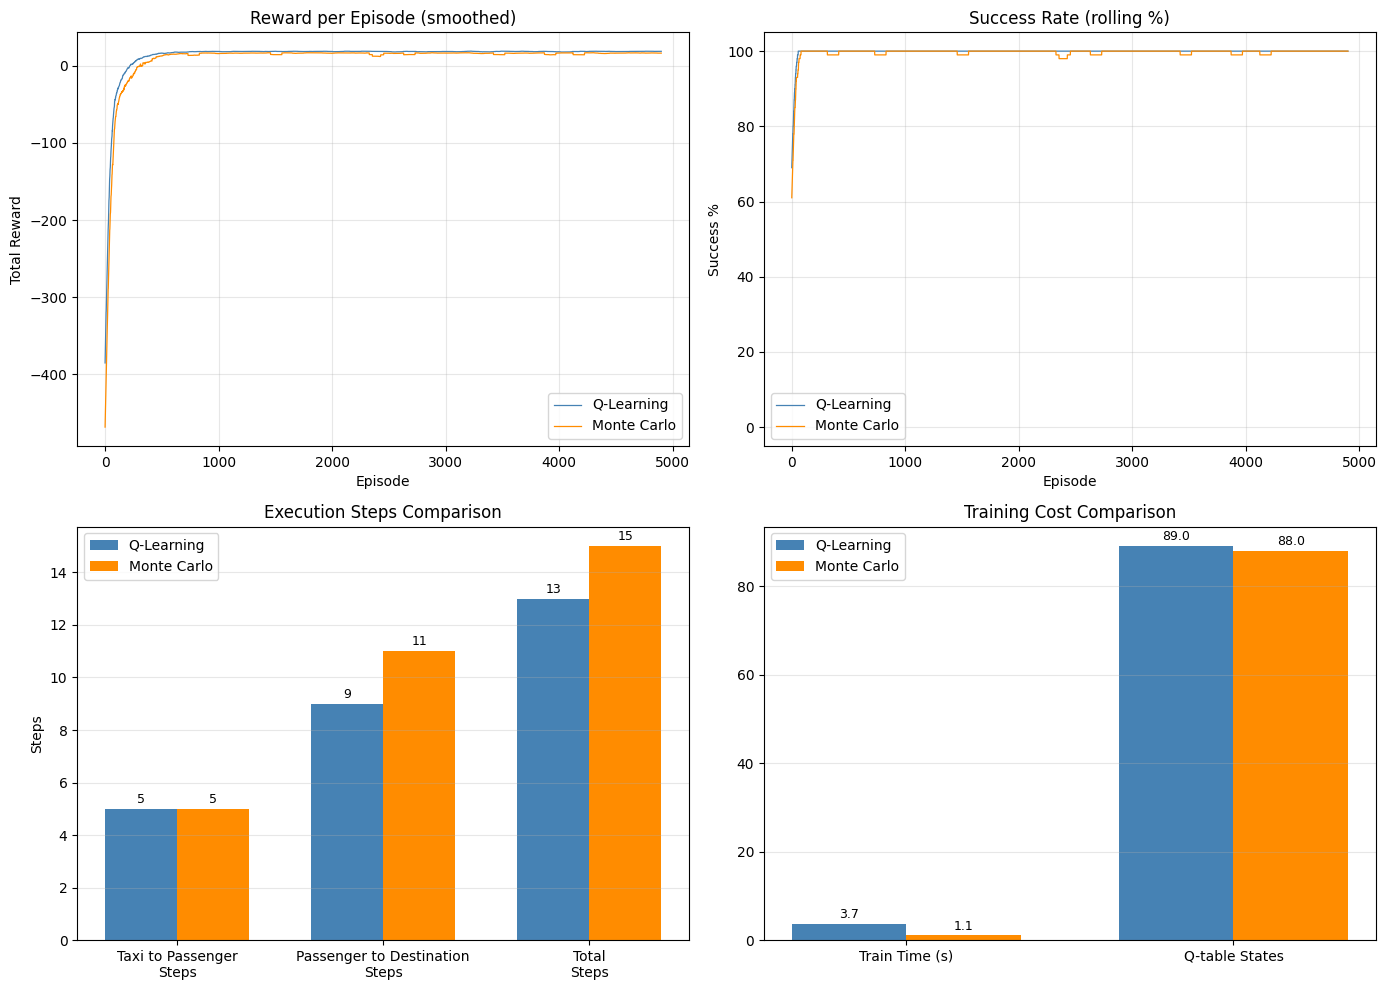

In [13]:
# ── Combined Comparison Plots ─────────────────────────────────────────────────
import matplotlib.pyplot as plt

def smooth(data, window=100):
    """Rolling average for smoothing noisy curves."""
    arr = np.array(data, dtype=float)
    if len(arr) < window:
        window = max(1, len(arr) // 5)
    kernel = np.ones(window) / window
    return np.convolve(arr, kernel, mode='valid')


if READY and 'ql_metrics' in dir() and 'mc_metrics' in dir():

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # ── 1. Overlay reward curves ─────────────────────────────────────────────
    ax = axes[0, 0]
    ax.plot(smooth(ql_metrics['episode_rewards']), label='Q-Learning',
            color='steelblue', linewidth=0.9)
    ax.plot(smooth(mc_metrics['episode_rewards']), label='Monte Carlo',
            color='darkorange', linewidth=0.9)
    ax.set_title('Reward per Episode (smoothed)')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Total Reward')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # ── 2. Overlay success rate curves ───────────────────────────────────────
    ax = axes[0, 1]
    ax.plot(smooth(ql_metrics['episode_successes']) * 100, label='Q-Learning',
            color='steelblue', linewidth=0.9)
    ax.plot(smooth(mc_metrics['episode_successes']) * 100, label='Monte Carlo',
            color='darkorange', linewidth=0.9)
    ax.set_title('Success Rate (rolling %)')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Success %')
    ax.set_ylim(-5, 105)
    ax.legend()
    ax.grid(True, alpha=0.3)


    # ── 3. Bar chart — Steps & Train time ────────────────────────────────────
    ax = axes[1, 0]
    labels   = ['Taxi to Passenger\nSteps', 'Passenger to Destination\nSteps', 'Total\nSteps']
    ql_vals  = [ql_phase1, ql_phase2, len(ql_path) - 1]
    mc_vals  = [mc_phase1, mc_phase2, len(mc_path) - 1]
    x        = np.arange(len(labels))
    width    = 0.35
    bars_ql  = ax.bar(x - width/2, ql_vals, width, label='Q-Learning', color='steelblue')
    bars_mc  = ax.bar(x + width/2, mc_vals, width, label='Monte Carlo', color='darkorange')
    ax.set_title('Execution Steps Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel('Steps')
    ax.legend()
    ax.bar_label(bars_ql, padding=2, fontsize=9)
    ax.bar_label(bars_mc, padding=2, fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

    # ── 4. Bar chart — Train time & Q-table size ────────────────────────────
    ax = axes[1, 1]
    labels2  = ['Train Time (s)', 'Q-table States']
    ql_vals2 = [ql_agent.train_time, len(ql_agent.q_table)]
    mc_vals2 = [mc_agent.train_time, len(mc_agent.q_table)]

    # Use twin axes because scales differ
    ax.set_title('Training Cost Comparison')
    x2       = np.arange(len(labels2))
    bars_ql2 = ax.bar(x2 - width/2, ql_vals2, width, label='Q-Learning', color='steelblue')
    bars_mc2 = ax.bar(x2 + width/2, mc_vals2, width, label='Monte Carlo', color='darkorange')
    ax.set_xticks(x2)
    ax.set_xticklabels(labels2)
    ax.legend()
    ax.bar_label(bars_ql2, padding=2, fontsize=9, fmt='%.1f')
    ax.bar_label(bars_mc2, padding=2, fontsize=9, fmt='%.1f')
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()
else:
    print('Skipping comparison plots — metrics not available.')


--- Q-Learning with alpha=0.01 ---
[Q-Learning] Training 5000 episodes | max_steps=200
  Episode     500/5000 | epsilon=0.0816 | success rate=88.0%
  Episode    1000/5000 | epsilon=0.0100 | success rate=100.0%
  Episode    1500/5000 | epsilon=0.0100 | success rate=100.0%
  Episode    2000/5000 | epsilon=0.0100 | success rate=100.0%
  Episode    2500/5000 | epsilon=0.0100 | success rate=100.0%
  Episode    3000/5000 | epsilon=0.0100 | success rate=100.0%
  Episode    3500/5000 | epsilon=0.0100 | success rate=100.0%
  Episode    4000/5000 | epsilon=0.0100 | success rate=100.0%
  Episode    4500/5000 | epsilon=0.0100 | success rate=100.0%
  Episode    5000/5000 | epsilon=0.0100 | success rate=100.0%
[Q-Learning] Done in 2.40s | Q-table states=89


--- Q-Learning with alpha=0.1 ---
[Q-Learning] Training 5000 episodes | max_steps=200
  Episode     500/5000 | epsilon=0.0816 | success rate=94.0%
  Episode    1000/5000 | epsilon=0.0100 | success rate=100.0%
  Episode    1500/5000 | epsilon=0.

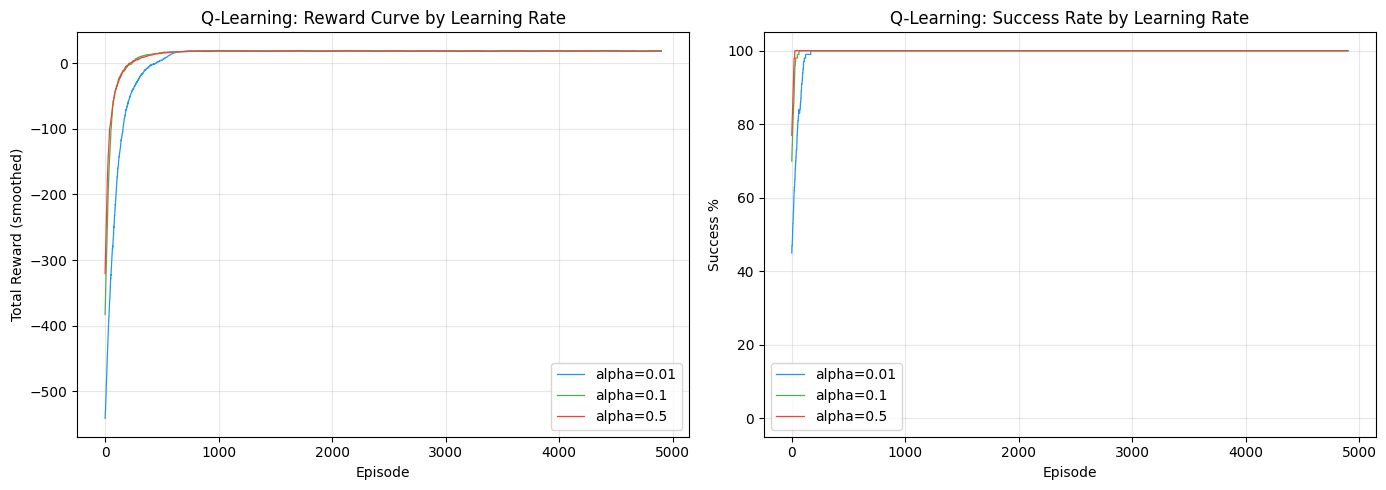


  LEARNING RATE COMPARISON (Q-Learning)
Alpha       Train Time (s)    Q-table Size    Final Success %
------------------------------------------------------------
0.01                  2.40              89             100.0%
0.1                   2.27              89             100.0%
0.5                   2.39              89             100.0%


In [14]:
# ── Experiment 1: Q-Learning with different learning rates (alpha) ────────────
if not READY:
    print('Skipping hyperparameter experiments — setup did not complete.')
else:
    alpha_values = [0.01, 0.1, 0.5]
    alpha_results = {}

    for alpha in alpha_values:
        print(f'\n--- Q-Learning with alpha={alpha} ---')
        agent = QLearningAgent(env, alpha=alpha)
        metrics = agent.train(episodes=EPISODES, max_steps=MAX_STEPS)
        alpha_results[alpha] = {
            'metrics': metrics,
            'train_time': agent.train_time,
            'q_table_size': len(agent.q_table),
        }

    # Plot overlaid reward curves
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = ['#2196F3', '#4CAF50', '#F44336']

    ax = axes[0]
    for (alpha, res), c in zip(alpha_results.items(), colors):
        ax.plot(smooth(res['metrics']['episode_rewards']),
                label=f'alpha={alpha}', color=c, linewidth=0.9)
    ax.set_title('Q-Learning: Reward Curve by Learning Rate')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Total Reward (smoothed)')
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    for (alpha, res), c in zip(alpha_results.items(), colors):
        ax.plot(smooth(res['metrics']['episode_successes']) * 100,
                label=f'alpha={alpha}', color=c, linewidth=0.9)
    ax.set_title('Q-Learning: Success Rate by Learning Rate')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Success %')
    ax.set_ylim(-5, 105)
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Summary table
    print('\n' + '=' * 60)
    print('  LEARNING RATE COMPARISON (Q-Learning)')
    print('=' * 60)
    print(f"{'Alpha':<10} {'Train Time (s)':>15} {'Q-table Size':>15} {'Final Success %':>18}")
    print('-' * 60)
    for alpha, res in alpha_results.items():
        final_success = np.mean(res['metrics']['episode_successes'][-500:]) * 100
        print(f'{alpha:<10} {res["train_time"]:>15.2f} {res["q_table_size"]:>15} {final_success:>17.1f}%')
    print('=' * 60)


--- Q-Learning with epsilon_decay=0.99 ---
[Q-Learning] Training 5000 episodes | max_steps=200
  Episode     500/5000 | epsilon=0.0100 | success rate=96.2%
  Episode    1000/5000 | epsilon=0.0100 | success rate=100.0%
  Episode    1500/5000 | epsilon=0.0100 | success rate=100.0%
  Episode    2000/5000 | epsilon=0.0100 | success rate=100.0%
  Episode    2500/5000 | epsilon=0.0100 | success rate=100.0%
  Episode    3000/5000 | epsilon=0.0100 | success rate=100.0%
  Episode    3500/5000 | epsilon=0.0100 | success rate=100.0%
  Episode    4000/5000 | epsilon=0.0100 | success rate=100.0%
  Episode    4500/5000 | epsilon=0.0100 | success rate=100.0%
  Episode    5000/5000 | epsilon=0.0100 | success rate=100.0%
[Q-Learning] Done in 2.45s | Q-table states=89


--- Monte Carlo with epsilon_decay=0.99 ---
[Monte Carlo] Training 5000 episodes | max_steps=200
  Episode     500/5000 | epsilon=0.0100 | success rate=6.8%
  Episode    1000/5000 | epsilon=0.0100 | success rate=0.0%
  Episode    1500/5

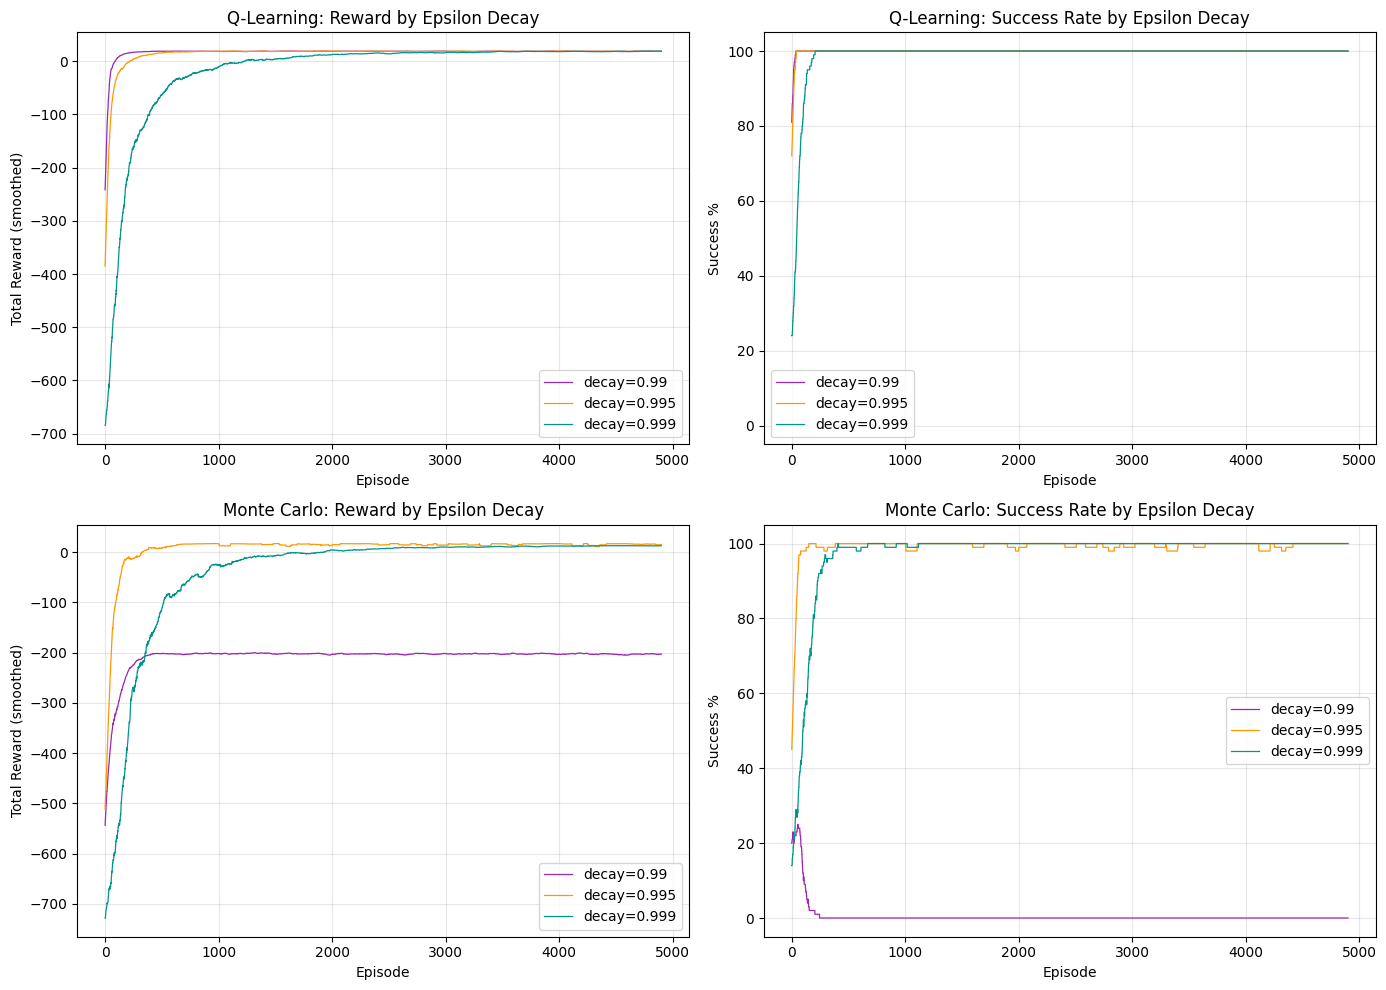


  EPSILON DECAY COMPARISON
Decay    Agent           Final Success %   Avg Final Reward
----------------------------------------------------------------------
0.99     Q-Learning               100.0%              18.4
         Monte Carlo                0.0%            -203.4
----------------------------------------------------------------------
0.995    Q-Learning               100.0%              18.5
         Monte Carlo              100.0%              15.8
----------------------------------------------------------------------
0.999    Q-Learning               100.0%              18.5
         Monte Carlo              100.0%              12.5
----------------------------------------------------------------------


In [15]:
# ── Experiment 2: Epsilon decay rate comparison (both agents) ─────────────────
if not READY:
    print('Skipping epsilon decay experiments.')
else:
    decay_values = [0.99, 0.995, 0.999]
    ql_decay_results = {}
    mc_decay_results = {}

    for decay in decay_values:
        print(f'\n--- Q-Learning with epsilon_decay={decay} ---')
        ql_var = QLearningAgent(env, epsilon_decay=decay)
        ql_m   = ql_var.train(episodes=EPISODES, max_steps=MAX_STEPS)
        ql_decay_results[decay] = ql_m

        print(f'\n--- Monte Carlo with epsilon_decay={decay} ---')
        mc_var = MonteCarloAgent(env, epsilon_decay=decay)
        mc_m   = mc_var.train(episodes=EPISODES, max_steps=MAX_STEPS)
        mc_decay_results[decay] = mc_m

    # Plot: 2x2 grid — reward and success for each agent
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    colors = ['#9C27B0', '#FF9800', '#009688']

    # Q-Learning reward by decay
    ax = axes[0, 0]
    for (decay, m), c in zip(ql_decay_results.items(), colors):
        ax.plot(smooth(m['episode_rewards']),
                label=f'decay={decay}', color=c, linewidth=0.9)
    ax.set_title('Q-Learning: Reward by Epsilon Decay')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Total Reward (smoothed)')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Q-Learning success by decay
    ax = axes[0, 1]
    for (decay, m), c in zip(ql_decay_results.items(), colors):
        ax.plot(smooth(m['episode_successes']) * 100,
                label=f'decay={decay}', color=c, linewidth=0.9)
    ax.set_title('Q-Learning: Success Rate by Epsilon Decay')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Success %')
    ax.set_ylim(-5, 105)
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Monte Carlo reward by decay
    ax = axes[1, 0]
    for (decay, m), c in zip(mc_decay_results.items(), colors):
        ax.plot(smooth(m['episode_rewards']),
                label=f'decay={decay}', color=c, linewidth=0.9)
    ax.set_title('Monte Carlo: Reward by Epsilon Decay')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Total Reward (smoothed)')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Monte Carlo success by decay
    ax = axes[1, 1]
    for (decay, m), c in zip(mc_decay_results.items(), colors):
        ax.plot(smooth(m['episode_successes']) * 100,
                label=f'decay={decay}', color=c, linewidth=0.9)
    ax.set_title('Monte Carlo: Success Rate by Epsilon Decay')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Success %')
    ax.set_ylim(-5, 105)
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Summary table
    print('\n' + '=' * 70)
    print('  EPSILON DECAY COMPARISON')
    print('=' * 70)
    print(f"{'Decay':<8} {'Agent':<14} {'Final Success %':>16} {'Avg Final Reward':>18}")
    print('-' * 70)
    for decay in decay_values:
        ql_s = np.mean(ql_decay_results[decay]['episode_successes'][-500:]) * 100
        ql_r = np.mean(ql_decay_results[decay]['episode_rewards'][-500:])
        mc_s = np.mean(mc_decay_results[decay]['episode_successes'][-500:]) * 100
        mc_r = np.mean(mc_decay_results[decay]['episode_rewards'][-500:])
        print(f'{decay:<8} {"Q-Learning":<14} {ql_s:>15.1f}% {ql_r:>17.1f}')
        print(f'{"":8} {"Monte Carlo":<14} {mc_s:>15.1f}% {mc_r:>17.1f}')
        print('-' * 70)
    print('=' * 70)